# 06. 数値線形代数と最適化 — 入力のズレはどれだけ増幅されるか

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 10. Exercises |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

紙の上の線形代数とコンピュータの線形代数は、似て非なるものです。
コンピュータの実数(浮動小数点数)は **有限個** しかなく、すべての計算に微小な丸め誤差が入ります。

この章の問いはひとつ:**その微小な誤差は、答えにどれだけ増幅されて現れるか?**

- 増幅率を測る数が **条件数**
- 「逆行列を作るな、`solve` を使え」の理由
- 大規模問題では直接法(LU)から **反復法**(共役勾配法)へ
- そして連立方程式・最小二乗は、実は **最適化問題**(勾配降下法・Newton 法)と同じものの別の顔

## 2. Problem — 同じ数学、違う答え

**問題 A** $0.1 + 0.2 = 0.3$ は、Python では `False` です。なぜ?

**問題 B** ほとんど平行な 2 直線の交点を求めたい。
データ(右辺)を 0.1% だけ動かしたら、交点が 10% 動いた。誰のせい?

**問題 C** 100 万次元の連立方程式を解きたい。
LU 分解は $O(n^3)$ — 宇宙の寿命でも終わらない。どうする?

A は浮動小数点の問題、B は条件数の問題、C は反復法の問題です。順に見ていきます。

In [1]:
# Shared setup.
import numpy as np
import matplotlib.pyplot as plt

from la_book import algebra, plotting

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

In [2]:
# Problem A: floating point numbers are a finite grid, not the real line.
print("0.1 + 0.2 == 0.3 :", 0.1 + 0.2 == 0.3)
print("0.1 + 0.2        =", f"{0.1 + 0.2:.20f}")
print("machine epsilon  =", np.finfo(np.float64).eps)

# Catastrophic cancellation: subtracting nearly equal numbers destroys digits.
x = 1.0 + 1e-15
print("\n(x - 1.0) where x = 1 + 1e-15:", x - 1.0, " (about 10% off from 1e-15)")

0.1 + 0.2 == 0.3 : False
0.1 + 0.2        = 0.30000000000000004441
machine epsilon  = 2.220446049250313e-16

(x - 1.0) where x = 1 + 1e-15: 1.1102230246251565e-15  (about 10% off from 1e-15)


## 3. Intuition — 条件数は「増幅率」

連立方程式 $Ax = b$ を「$b$ を入れると $x$ が出てくる装置」と考えます。
入力 $b$ に混じった相対誤差(測定誤差・丸め誤差)は、出力 $x$ では最大で

$$
\kappa(A) = \frac{\sigma_{\max}}{\sigma_{\min}}
$$

倍に増幅されます。これが **条件数** です(特異値は 05 章の SVD)。

幾何的には:2 直線がほぼ平行だと、片方をわずかに動かしただけで交点が大きく滑る。
「ほぼ平行 = ほぼランク落ち = $\sigma_{\min}$ が小さい = 条件数が大きい」。
条件数は **問題そのものの性質** であり、どんな優秀なアルゴリズムでも回避できません。

## 4. Visualization — ほぼ平行な直線の交点は滑る

条件の良い系と悪い系で、右辺 $b$ に同じ大きさのノイズを入れて
解(交点)がどれだけ動くかを比べます。

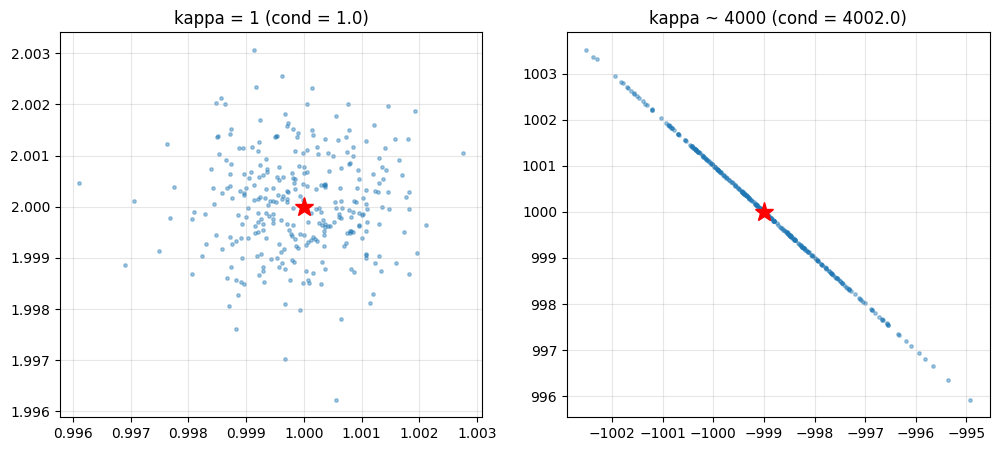

solution scatter (std), good: [1. 2.] -> [0.0011 0.001 ]
condition numbers: 1.0 4002.000750124839


In [3]:
# Well-conditioned vs ill-conditioned: same noise in b, very different scatter in x.
A_good = np.array([[1.0, 0.0], [0.0, 1.0]])          # orthogonal lines
A_bad = np.array([[1.0, 1.0], [1.0, 1.001]])         # nearly parallel lines
b0 = np.array([1.0, 2.0])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, A, name in [(axes[0], A_good, "kappa = 1"), (axes[1], A_bad, "kappa ~ 4000")]:
    sols = []
    for _ in range(300):
        b_noisy = b0 + 1e-3 * rng.standard_normal(2)   # 0.1%-ish noise
        sols.append(np.linalg.solve(A, b_noisy))
    sols = np.array(sols)
    x_star = np.linalg.solve(A, b0)
    ax.scatter(sols[:, 0], sols[:, 1], s=6, alpha=0.4)
    ax.plot(*x_star, "r*", ms=14)
    ax.set_title(f"{name} (cond = {np.linalg.cond(A):.1f})")
    ax.grid(alpha=0.3)
plt.show()
print("solution scatter (std), good:", np.linalg.solve(A_good, b0), "->",
      np.std([np.linalg.solve(A_good, b0 + 1e-3 * rng.standard_normal(2)) for _ in range(300)], axis=0))
print("condition numbers:", np.linalg.cond(A_good), np.linalg.cond(A_bad))

## 5. Definition — 機械イプシロン・条件数・誤差限界

**浮動小数点(IEEE 754 倍精度)**: 仮数部 52 ビット。
1 の次に表現できる数との差が **機械イプシロン** $\varepsilon \approx 2.2 \times 10^{-16}$。
すべての基本演算は相対誤差 $\varepsilon$ 以内で丸められます。

**条件数**: $\kappa(A) = \|A\| \|A^{-1}\| = \sigma_{\max} / \sigma_{\min}$(2-ノルムの場合)。

**誤差限界**: $Ax = b$ で $b$ が $\delta b$ だけずれたときの解のずれ $\delta x$ は

$$
\frac{\|\delta x\|}{\|x\|} \;\le\; \kappa(A)\, \frac{\|\delta b\|}{\|b\|}
$$

**経験則**: 倍精度(16 桁)で条件数が $10^k$ なら、答えの信頼できる桁は約 $16 - k$ 桁。
$\kappa > 10^{16}$ なら答えは数値的に無意味です。

## 6. Computation — solve vs inv、直接法 vs 反復法

### `solve` と `inv` の違い

$x = A^{-1}b$ と書きたくなりますが、**逆行列を実際に作ってはいけません**。

- `solve(A, b)`: LU 分解 + 代入。速くて誤差が小さい。
- `inv(A) @ b`: 逆行列の全成分を計算(=方程式を $n$ 本解く)してから掛ける。
  遅いうえに余計な丸め誤差が乗る。

条件数が悪い行列(Hilbert 行列)で差を見ます。

In [4]:
# Hilbert matrices: famously ill-conditioned. Compare solve vs inv accuracy.
from scipy.linalg import hilbert

for n in [4, 8, 12]:
    H = hilbert(n)
    x_true = np.ones(n)
    b = H @ x_true
    err_solve = np.linalg.norm(np.linalg.solve(H, b) - x_true)
    err_inv = np.linalg.norm(np.linalg.inv(H) @ b - x_true)
    print(f"n = {n:>2}: cond = {np.linalg.cond(H):.1e}   "
          f"err(solve) = {err_solve:.1e}   err(inv) = {err_inv:.1e}")

n =  4: cond = 1.6e+04   err(solve) = 8.3e-14   err(inv) = 1.3e-12
n =  8: cond = 1.5e+10   err(solve) = 1.7e-07   err(inv) = 2.6e-06
n = 12: cond = 1.8e+16   err(solve) = 1.1e+00   err(inv) = 3.3e+01


In [5]:
# Speed: solve beats inv as well (inv solves n systems to build A^{-1}).
import time

n = 800
A_big = rng.standard_normal((n, n)) + n * np.eye(n)
b_big = rng.standard_normal(n)

t0 = time.perf_counter(); x1 = np.linalg.solve(A_big, b_big); t1 = time.perf_counter()
t2 = time.perf_counter(); x2 = np.linalg.inv(A_big) @ b_big; t3 = time.perf_counter()
print(f"solve: {1e3 * (t1 - t0):6.1f} ms   inv @ b: {1e3 * (t3 - t2):6.1f} ms")
print("answers agree:", np.allclose(x1, x2))

solve: 3688.9 ms   inv @ b: 4740.2 ms
answers agree: True


### 反復法 — 解に「近づいていく」

$n$ が巨大(かつ $A$ が疎)なとき、$O(n^3)$ の直接法は使えません。
反復法は「行列とベクトルの積 $Av$」だけを繰り返して解に近づきます。

代表が **共役勾配法(CG)**:対称正定値な $A$ 専用で、
$f(x) = \frac{1}{2}x^\top A x - b^\top x$ の最小化として $Ax = b$ を解きます
($\nabla f = Ax - b = 0$ が解の条件であることに注意 — ここで最適化と接続します)。

### 勾配降下法と比べる

- **勾配降下法(GD)**: いま立っている場所の最急降下方向 $-\nabla f$ に少し進む、を繰り返す。
- **CG**: 過去に進んだ方向と「$A$-直交」な方向だけを選んで進む。同じ方向を 2 度直さないので、
  理論上 $n$ 回で厳密解に到達。

条件数が悪いと GD は谷底でジグザグして遅くなりますが、CG は係数 $\sqrt{\kappa}$ で済みます。

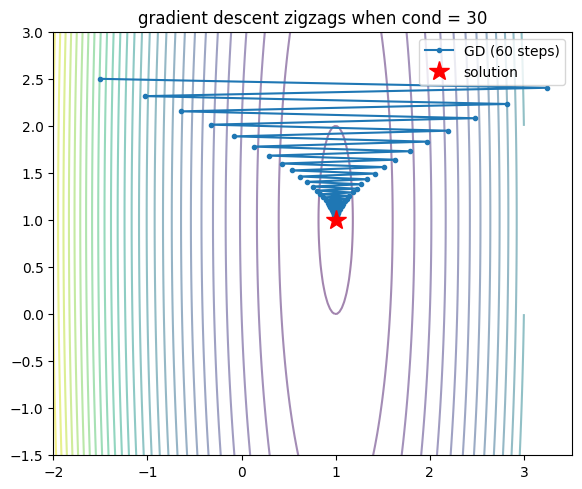

CG iterations to machine precision: 2 (n = 2 -> exact in 2 steps)


In [6]:
# GD zigzags in a narrow valley; CG cuts straight through.
kappa = 30.0
A_q = np.array([[kappa, 0.0], [0.0, 1.0]])    # condition number = 30
b_q = np.array([kappa, 1.0])                  # solution = (1, 1)
x_star = np.linalg.solve(A_q, b_q)

path_gd = algebra.gradient_descent_quadratic(A_q, b_q, lr=1.9 / kappa, n_iter=60,
                                             x0=np.array([-1.5, 2.5]))
x_cg, res_cg = algebra.conjugate_gradient(A_q, b_q, x0=np.array([-1.5, 2.5]))

# Contours of f plus both optimization paths.
g1, g2 = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 3, 200))
f_vals = 0.5 * (A_q[0, 0] * g1**2 + A_q[1, 1] * g2**2) - b_q[0] * g1 - b_q[1] * g2

plt.figure(figsize=(8, 5.5))
plt.contour(g1, g2, f_vals, levels=30, alpha=0.5)
plt.plot(path_gd[:, 0], path_gd[:, 1], "o-", ms=3, label=f"GD ({len(path_gd) - 1} steps)")
plt.plot(*x_star, "r*", ms=15, label="solution")
plt.legend(); plt.gca().set_aspect("equal")
plt.title(f"gradient descent zigzags when cond = {kappa:.0f}")
plt.show()
print("CG iterations to machine precision:", len(res_cg) - 1, "(n = 2 -> exact in 2 steps)")

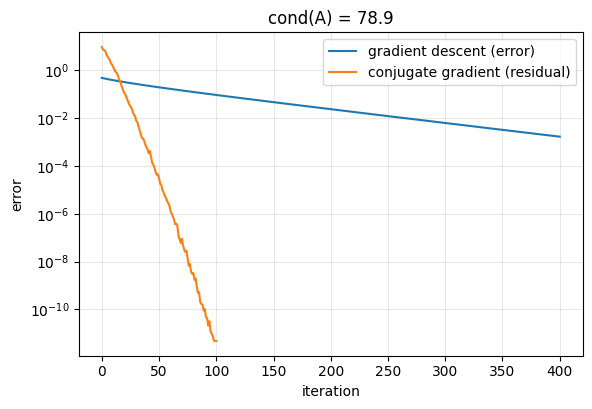

In [7]:
# Convergence comparison on a larger SPD system.
n = 100
M = rng.standard_normal((n, n))
A_spd = M @ M.T + 5 * np.eye(n)
b_spd = rng.standard_normal(n)
x_sol = np.linalg.solve(A_spd, b_spd)

lam_max = np.linalg.eigvalsh(A_spd).max()
path = algebra.gradient_descent_quadratic(A_spd, b_spd, lr=1.0 / lam_max, n_iter=400)
gd_err = np.linalg.norm(path - x_sol, axis=1)
_, cg_res = algebra.conjugate_gradient(A_spd, b_spd, tol=1e-12)

plotting.plot_convergence({"gradient descent (error)": gd_err,
                           "conjugate gradient (residual)": cg_res})
plt.title(f"cond(A) = {np.linalg.cond(A_spd):.1f}")
plt.show()

### Newton 法 — 曲がり方まで使う

勾配降下法は 1 階微分(傾き)だけを使いますが、**Newton 法** は 2 階微分(Hessian、曲がり方)も使い、

$$
x_{k+1} = x_k - H(x_k)^{-1} \nabla f(x_k)
$$

と更新します。2 次関数なら **1 回で厳密解** に到達します
(各ステップで連立一次方程式 $H \delta = \nabla f$ を解いている点に注意 —
最適化の内側にも線形代数がいます)。

In [8]:
# Newton's method on a non-quadratic function: quadratic convergence near the optimum.
def grad_f(x):
    # f(x, y) = (x - 1)^4 + (y + 0.5)^2 (a smooth bowl, minimum at (1, -0.5))
    return np.array([4 * (x[0] - 1) ** 3, 2 * (x[1] + 0.5)])

def hess_f(x):
    return np.array([[12 * (x[0] - 1) ** 2, 0.0], [0.0, 2.0]])

path_newton = algebra.newton_method(grad_f, hess_f, x0=np.array([3.0, 2.0]), n_iter=15)
errs = np.linalg.norm(path_newton - np.array([1.0, -0.5]), axis=1)
print("error per Newton step:")
for i, e in enumerate(errs[:8]):
    print(f"  step {i}: {e:.2e}")

error per Newton step:
  step 0: 3.20e+00
  step 1: 1.33e+00
  step 2: 8.89e-01
  step 3: 5.93e-01
  step 4: 3.95e-01
  step 5: 2.63e-01
  step 6: 1.76e-01
  step 7: 1.17e-01


## 7. Invariant — 直交変換は条件数を変えない

直交行列 $Q$ を掛けても特異値は変わらないので(05 章)、

$$
\kappa(QA) = \kappa(A)
$$

**直交変換は誤差を増幅しない** — これが数値線形代数の設計原理です。
QR 分解・Householder 変換・SVD ベースの手法が「安定」と呼ばれるのは、
仕事のほとんどを直交変換で済ませるからです。
逆に、三角行列や $A^\top A$ の形成は条件数を悪化させ得ます(次節)。

In [9]:
# Orthogonal transforms leave the condition number unchanged.
A_any = rng.standard_normal((5, 5)) + 2 * np.eye(5)
Q_rand, _ = np.linalg.qr(rng.standard_normal((5, 5)))
print("cond(A)   =", np.linalg.cond(A_any))
print("cond(Q A) =", np.linalg.cond(Q_rand @ A_any))

cond(A)   = 4.38939252806998
cond(Q A) = 4.389392528069983


## 8. Failure Mode — 正規方程式で条件数が2乗になる

最小二乗を正規方程式 $A^\top A x = A^\top b$ で解くと、

$$
\kappa(A^\top A) = \kappa(A)^2
$$

条件数が **2 乗** になります。$\kappa(A) = 10^6$ なら $\kappa(A^\top A) = 10^{12}$ —
有効桁が一気に 6 桁消えます。QR 分解(または SVD)経由なら $\kappa(A)$ のままです。

In [10]:
# Normal equations square the condition number; QR-based lstsq does not.
m, deg = 60, 14
t = np.linspace(0, 1, m)
A_v = np.vander(t, deg + 1)                  # ill-conditioned Vandermonde
x_true = np.ones(deg + 1)
b_v = A_v @ x_true

print(f"cond(A)     = {np.linalg.cond(A_v):.1e}")
print(f"cond(A^T A) = {np.linalg.cond(A_v.T @ A_v):.1e}   (squared!)")

x_normal = np.linalg.solve(A_v.T @ A_v, A_v.T @ b_v)     # normal equations
x_qr = np.linalg.lstsq(A_v, b_v, rcond=None)[0]          # QR/SVD based

print("error via normal equations:", np.linalg.norm(x_normal - x_true))
print("error via lstsq (QR/SVD)  :", np.linalg.norm(x_qr - x_true))

cond(A)     = 2.3e+10
cond(A^T A) = 1.5e+18   (squared!)
error via normal equations: 8332.46325224966
error via lstsq (QR/SVD)  : 3.513757049226849e-06


**学習率の選択ミスも典型的な失敗です。** 勾配降下法の固定ステップ $\eta$ は
$\eta < 2 / \lambda_{\max}$ でないと発散します。最大固有値が安定性の境界を決める —
これも固有値の仕事です。

In [11]:
# GD diverges when the learning rate exceeds 2 / lambda_max.
lam_max_q = np.linalg.eigvalsh(A_q).max()
for lr in [1.8 / lam_max_q, 2.05 / lam_max_q]:
    path = algebra.gradient_descent_quadratic(A_q, b_q, lr=lr, n_iter=100)
    final_err = np.linalg.norm(path[-1] - x_star)
    print(f"lr = {lr:.4f} ({lr * lam_max_q:.2f}/lam_max): final error = {final_err:.2e}")

lr = 0.0600 (1.80/lam_max): final error = 2.05e-03
lr = 0.0683 (2.05/lam_max): final error = 1.32e+02


## 9. Application — 最小二乗・機械学習・大規模シミュレーション

**最小二乗と最適化の接続(まとめ)。** 同じ問題の 3 つの顔:

| 顔 | 式 | 章 |
|---|---|---|
| 幾何 | $b$ を $\mathrm{col}(A)$ に正射影 | 04 |
| 代数 | 正規方程式 $A^\top A x = A^\top b$ | 04 |
| 最適化 | $\min_x \|Ax - b\|^2$ を GD/CG/QR で解く | 06 |

機械学習の訓練はほぼすべて「巨大な最小二乗(の一般化)を反復法で解く」営みです。
深層学習の SGD は勾配降下法の確率版で、学習率と曲率(Hessian の固有値)の関係も
ここで見た構図がそのまま生きています。

**シミュレーション。** 偏微分方程式を離散化すると、数百万次元の疎な連立方程式になります。
解くのは前処理付き CG や GMRES。条件数を下げる「前処理」が実務の主戦場です。

## 10. Exercises

1. `0.1 + 0.2 != 0.3` を確認し、`abs(a - b) < tol` 方式と `np.isclose` で正しく比較せよ。
2. $A = \begin{pmatrix} 1 & 1 \\ 1 & 1.0001 \end{pmatrix}$ の条件数を SVD から手計算し、
   `np.linalg.cond` と照合せよ。
3. Hilbert 行列($n = 10$)で $b$ に $10^{-10}$ のノイズを入れ、解の変化を測れ。
   誤差限界 $\kappa \cdot \|\delta b\| / \|b\|$ と比較せよ。
4. 条件数 $\kappa = 100$ の 2 次関数で GD の収束を観察し、$\kappa = 10$ の場合と
   反復回数を比較せよ。
5. CG の残差履歴をプロットし、理論どおり $n$ 回以内で(数値誤差の範囲で)
   収束することを確認せよ。
6. (発展)`scipy.sparse` で 3 重対角行列($n = 10^5$)を作り、
   `scipy.sparse.linalg.cg` で解いてみよ。密行列の `solve` とメモリ・時間を比べよ。

## 11. Advanced Notes

**後退安定性。** 良いアルゴリズムの定義は「誤差が小さい」ではなく
「**少しずれた問題を厳密に解いている**」($\hat{x}$ が $(A + \delta A)\hat{x} = b$,
$\|\delta A\| = O(\varepsilon)\|A\|$ の厳密解)です。
このとき誤差は $\kappa(A) \varepsilon$ で抑えられ、「アルゴリズムの責任($\varepsilon$)」と
「問題の責任($\kappa$)」が分離されます。部分ピボット付き LU、Householder QR は後退安定です。

**CG の収束レート。** $\kappa = \kappa(A)$ として

$$
\|x_k - x^*\|_A \le 2 \left( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)^k \|x_0 - x^*\|_A
$$

GD の同種の評価は $\left(\frac{\kappa - 1}{\kappa + 1}\right)^k$ で、$\kappa$ が $\sqrt{\kappa}$ に
改善されるのが CG の本質的な得です。さらに CG は固有値が **クラスター** していれば
クラスター数程度の反復で実質収束します。前処理 $M^{-1}A$ の狙いはこのクラスター化です。

**条件数の幾何学的解釈。** $\kappa(A)$ は「$A$ が単位球を楕円に移すときの、
最長軸と最短軸の比」。$\kappa = \infty$(特異)は楕円がぺたんこ、
つまり 02 章のランク落ちです。「ランク落ちは条件数の極限」という見方が、
厳密な数学(ランク)と数値計算(条件数)をつなぎます。

**反復法の系譜。** 対称正定値 → CG、対称不定 → MINRES、非対称 → GMRES / BiCGSTAB。
いずれも「Krylov 部分空間 $\mathrm{span}\{b, Ab, A^2b, \dots\}$ の中で最良の近似を探す」
という統一的な見方ができます。

## 二次形式上の勾配降下(インタラクティブ)

異方的な二次の谷 $f(x) = \tfrac12 x^\top A x - b^\top x$ の等高線上で、勾配降下がどう最小へ向かうか。スライダーで 1 ステップずつ辿れる。

In [12]:
import plotly.io as pio
from la_book import plotting as viz

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = viz.plotly_gradient_descent_quadratic()
fig.show()